<font color="green" size="5"><b>Exploratory Data Analysis (EDA)</b></font>

In this step, we explore the final analytical dataset to understand business performance and identify key patterns.

The goal of this analysis is to answer important business questions such as:

- What drives revenue?
- Which customer segment is most valuable?
- Which product categories generate the most revenue?
- Where are losses occurring due to cancellations or returns?
- Which payment methods have higher risk?

The analysis includes:

- Revenue trends over time
- Revenue by country
- Revenue by customer segment
- Product category performance
- Cancellation and return rates
- Payment success rate

<font color="green" size="4"><b>Importing necessary libraries</b></font>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<font color="green" size="4"><b>Loading the datasets</b></font>

In [3]:
df = pd.read_csv("../Data/Final_Dataset.csv")

<font color="green" size="4"><b>Revenue Trend (Daily)</b></font>

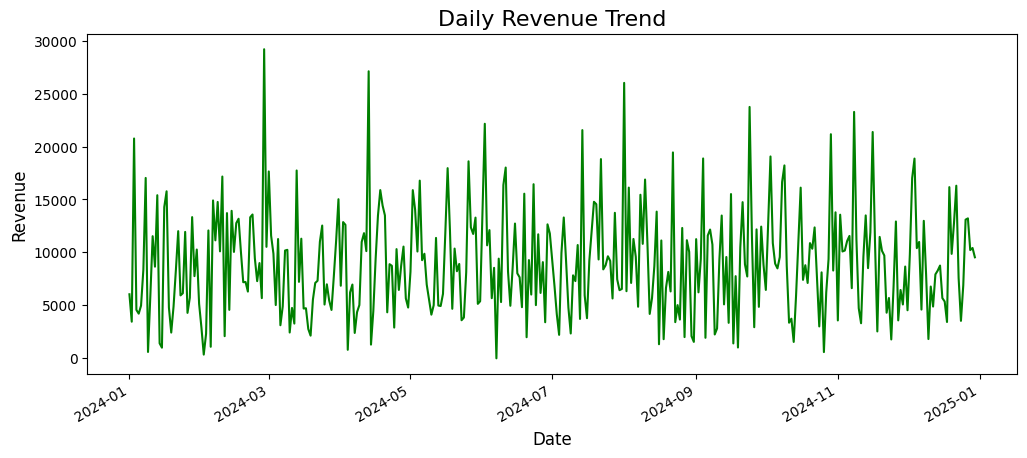

In [4]:
df["order_date"] = pd.to_datetime(df["order_date"])

daily_revenue = df.groupby("order_date")["revenue"].sum()

daily_revenue.plot(figsize=(12,5), color="green")
plt.title("Daily Revenue Trend", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Revenue", fontsize=12)
plt.show()

<font color="#01c094" size="4"><b>Insight</b></font>

The daily revenue trend shows fluctuations in sales activity over time.  
Some days generate significantly higher revenue, which may indicate promotional periods or higher customer activity.

This trend analysis helps identify sales patterns and potential seasonality.

<font color="green" size="4"><b>Revenue by Country</b></font>

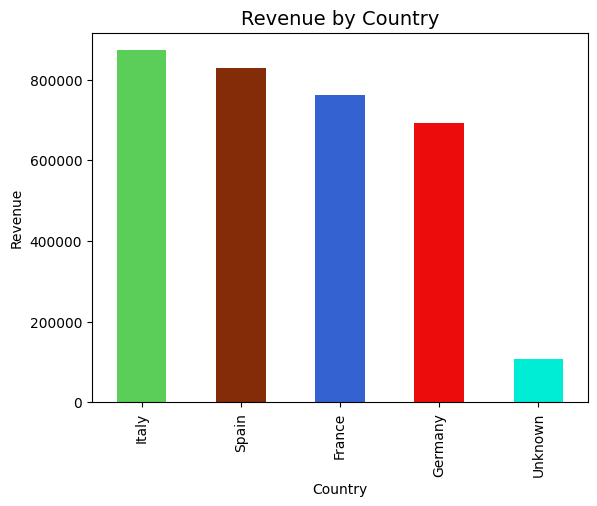

In [5]:
revenue_country = df.groupby("country")["revenue"].sum().sort_values(ascending=False)

revenue_country.plot(kind="bar", color=["#5ace59", "#842b07", "#3463d1", "#ec0c0c", "#00edd5"])
plt.title("Revenue by Country", fontsize=14)
plt.xlabel("Country", fontsize=10)
plt.ylabel("Revenue", fontsize=10)
plt.show()

<font color="#01c094" size="4"><b>Insight</b></font>

Revenue distribution varies across countries.  
The country with the highest revenue contribution represents the most important market for the company.

Understanding geographic revenue distribution helps identify where marketing efforts should be focused.

<font color="green" size="4"><b>Revenue by Segment</b></font>

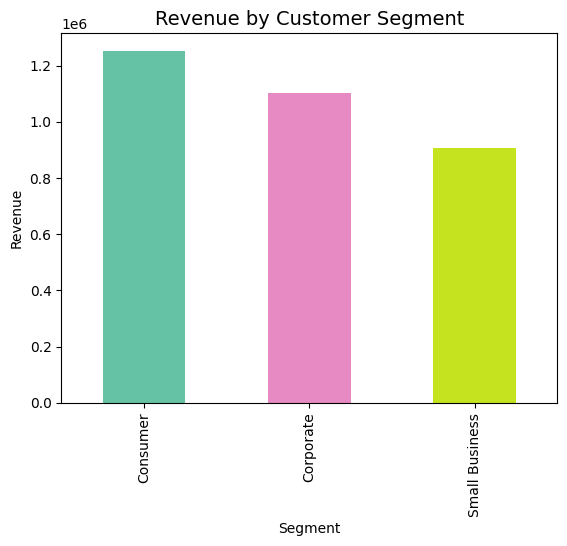

In [6]:
revenue_segment = df.groupby("segment")["revenue"].sum()

revenue_segment.plot(kind="bar", color=["#66c2a5","#e78ac3", "#c6e320"])
plt.title("Revenue by Customer Segment", fontsize=14)
plt.xlabel("Segment", fontsize=10)
plt.ylabel("Revenue", fontsize=10)
plt.show()

<font color="#01c094" size="4"><b>Insight</b></font>

Customer segments contribute differently to total revenue.  
Identifying the most profitable segment helps the company focus on the most valuable customers.

<font color="green" size="4"><b>Category Performance</b></font>

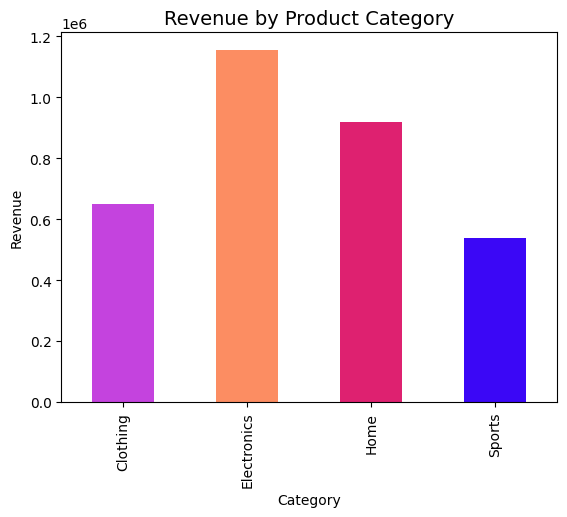

In [7]:
category_revenue = df.groupby("category")["revenue"].sum()

category_revenue.plot(kind="bar", color=["#c443de", "#fc8d62", "#de2170", "#3b07f6"])
plt.title("Revenue by Product Category", fontsize=14)
plt.xlabel("Category", fontsize=10)
plt.ylabel("Revenue", fontsize=10)
plt.show()

<font color="#01c094" size="4"><b>Insight</b></font>

Product category performance highlights which categories generate the most revenue.

High-performing categories may indicate strong customer demand and could be prioritized in marketing and inventory planning.

<font color="green" size="4"><b>Return & Cancellation Rate</b></font>

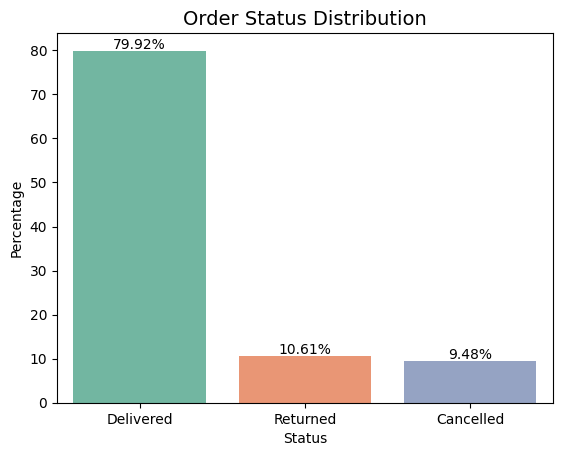

In [10]:
rate=df["status"].value_counts(normalize=True) * 100

sns.barplot(x=rate.index, y=rate.values, palette="Set2",hue=rate.index,legend=False)
plt.title("Order Status Distribution", fontsize=14)
plt.xlabel("Status", fontsize=10)
plt.ylabel("Percentage", fontsize=10)

for i, v in enumerate(rate.values):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center', fontsize=10)
plt.show()


<font color="#01c094" size="4"><b>Insight</b></font>

The distribution of order statuses shows the proportion of delivered, returned, and cancelled orders.

Returns and cancellations represent potential revenue losses and may indicate operational issues or product dissatisfaction.

<font color="green" size="4"><b>Payment Success Rate</b></font>

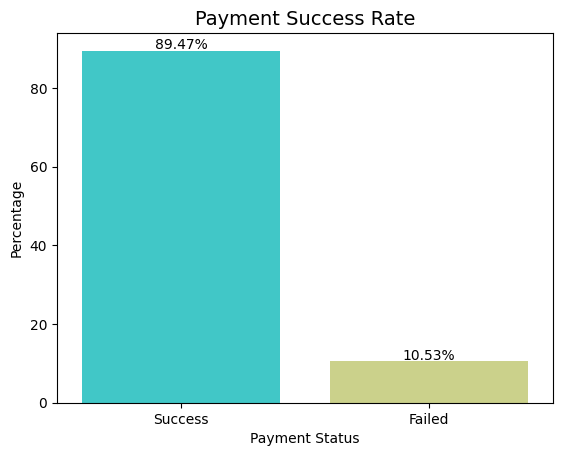

In [11]:
rate=df["payment_status"].value_counts(normalize=True) * 100

sns.barplot(x=rate.index, y=rate.values, palette="rainbow",hue=rate.index,legend=False)
plt.title("Payment Success Rate", fontsize=14)
plt.xlabel("Payment Status", fontsize=10)
plt.ylabel("Percentage", fontsize=10)

for i, v in enumerate(rate.values):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center', fontsize=10)
plt.show()


<font color="#01c094" size="4"><b>Insight</b></font>

Payment success rate indicates how reliable each payment transaction is.

A high failure rate for a specific payment method may signal payment processing issues or higher fraud risk.